<a href="https://colab.research.google.com/github/josedmaldonado-r/Distribucion-y-Probabilidad/blob/main/APE09_APE10_Pruebas_Hipotesis_Loja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pruebas de Hipótesis Estadística sobre la Región de Loja
### Encuesta ENEMDU – Módulo de Confianza del Consumidor (Enero 2026)

**Curso:** Distribución y Probabilidad
**Fuente de datos:** `enemdu_consumidor_2026_01.csv` (INEC) — Formulario `202602_Formulario_ENEMDU`, Sección 6: *Índice de Confianza al Consumidor*.

Este notebook desarrolla dos ejercicios de **pruebas de hipótesis unimuestrales**:

| Tarea | Prueba | Parámetro | Variable INEC |
|---|---|---|---|
| APE 09 | Z para una proporción | $p$ = proporción de hogares que perciben deterioro del empleo | `c20a` |
| APE 10 | T de Student para una media | $\mu$ = saldo neto de percepción económica del hogar | `c01` (recodificada) |

Se filtra el dataset nacional para conservar únicamente los registros correspondientes a la **provincia de Loja** (código de provincia `11` según la codificación DPA del INEC, contenida en los dos primeros dígitos del campo `ciudad`).


In [ ]:
# ==========================================================
# LIBRERÍAS
# scipy.stats  -> pruebas estadísticas paramétricas (T de Student)
# statsmodels  -> prueba Z para proporciones (proportions_ztest)
# pandas/numpy -> manejo y limpieza de datos
# matplotlib   -> visualización de las distribuciones muestrales
# ==========================================================
import pandas as pd
import numpy as np
import scipy.stats as st
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)


## 1. Carga del dataset y filtrado geográfico (Provincia de Loja)

El archivo utiliza `;` como separador. El campo `ciudad` almacena el código DPA
(Provincia-Cantón-Parroquia) sin ceros a la izquierda, por lo que se normaliza
a 6 dígitos con `zfill(6)` antes de extraer los dos primeros dígitos, que
identifican la **provincia** (código `11` = Loja).

In [ ]:
# Carga del dataset (separador ';' y codificación UTF-8 con BOM)
df = pd.read_csv('enemdu_consumidor_2026_01__1_.csv', sep=';', encoding='utf-8-sig')

# El código de ciudad viene sin ceros a la izquierda (ej. 10150 -> 010150)
# Se normaliza a 6 dígitos para poder extraer correctamente el código de provincia
df['ciudad_str'] = df['ciudad'].astype(str).str.zfill(6)
df['provincia_cod'] = df['ciudad_str'].str[:2]

# Filtro: provincia de Loja = código '11'
loja = df[df['provincia_cod'] == '11'].copy()

print(f"Registros totales en el dataset nacional : {len(df)}")
print(f"Registros correspondientes a Loja        : {len(loja)}")
loja[['area', 'c01', 'c02', 'c18', 'c19', 'c20a', 'c21a']].head()


Registros totales en el dataset nacional : 8791
Registros correspondientes a Loja        : 300


,area,c01,c02,c18,c19,c20a,c21a
4595,1,2,2,1,3,3,3
4596,1,2,2,2,2,2,3
4597,1,2,2,3,2,3,3
4598,1,2,2,3,2,3,3
4599,1,2,2,3,2,3,3


## 2. APE 09 — Prueba de Hipótesis Unimuestral (Z para una proporción)

### Variable analizada
`c20a`: *"Con relación a los 3 meses anteriores, ¿considera usted que la situación en
Ecuador para encontrar/mejorar un puesto de trabajo es: Mejor(1) / Igual(2) / Peor(3)?"*

Se define el parámetro crítico $p$ como la **proporción de hogares de Loja que perciben
que la situación laboral del país ha empeorado** (`c20a == 3`).

### Planteamiento de hipótesis

$$
H_0: p \le 0.50 \qquad \text{(no existe una mayoría pesimista respecto al empleo)}
$$
$$
H_1: p > 0.50 \qquad \text{(existe una mayoría de hogares que percibe deterioro laboral)}
$$

### Estadístico de prueba

Dado que $n \cdot \hat{p}$ y $n\cdot(1-\hat p)$ son ambos mayores a 5 (condición de
aproximación normal), se emplea el estadístico **Z para una proporción**:

$$
Z = \frac{\hat{p} - p_0}{\sqrt{\dfrac{p_0 (1-p_0)}{n}}}
$$

donde $\hat p$ es la proporción muestral, $p_0 = 0.50$ es el valor de referencia bajo
$H_0$, y $n$ es el tamaño de la submuestra de Loja. Se usa un contraste de **una sola
cola (derecha)** y nivel de significancia $\alpha = 0.05$.

In [ ]:
# ---------------------------------------------------------
# APE 09: Prueba Z para una proporción (statsmodels)
# ---------------------------------------------------------

# Condición de éxito: percepción de que el empleo empeoró (código 3 = "Peor")
n_loja = len(loja)
exitos = (loja['c20a'] == 3).sum()      # número de hogares que reportan "Peor"
p_hat = exitos / n_loja

p0 = 0.50          # valor de referencia bajo H0
alpha = 0.05        # nivel de significancia

# proportions_ztest calcula el estadístico Z y el valor-p
# alternative='larger' -> contraste de cola derecha: H1: p > p0
z_stat, p_value = proportions_ztest(count=exitos, nobs=n_loja, value=p0,
                                     alternative='larger')

print("----- APE 09: Prueba Z de una proporción -----")
print(f"n (Loja)                 = {n_loja}")
print(f"Hogares que perciben 'Peor' (éxitos) = {exitos}")
print(f"Proporción muestral p_hat = {p_hat:.4f}")
print(f"Estadístico Z             = {z_stat:.4f}")
print(f"Valor-p                   = {p_value:.6f}")
print(f"Nivel de significancia α  = {alpha}")


----- APE 09: Prueba Z de una proporción -----
n (Loja)                 = 300
Hogares que perciben 'Peor' (éxitos) = 171
Proporción muestral p_hat = 0.5700
Estadístico Z             = 2.4490
Valor-p                   = 0.007163
Nivel de significancia α  = 0.05


In [ ]:
# Decisión estadística basada en el valor-p
print("----- Decisión estadística (APE 09) -----")
if p_value < alpha:
    print(f"Valor-p ({p_value:.6f}) < α ({alpha})  ->  Se RECHAZA H0.")
    print("Conclusión: existe evidencia estadísticamente significativa de que MÁS DEL 50%")
    print("de los hogares de Loja perciben que la situación del empleo ha empeorado.")
else:
    print(f"Valor-p ({p_value:.6f}) >= α ({alpha})  ->  No se rechaza H0.")
    print("Conclusión: no hay evidencia suficiente para afirmar que la mayoría de los")
    print("hogares de Loja percibe un deterioro del empleo.")


----- Decisión estadística (APE 09) -----
Valor-p (0.007163) < α (0.05)  ->  Se RECHAZA H0.
Conclusión: existe evidencia estadísticamente significativa de que MÁS DEL 50%
de los hogares de Loja perciben que la situación del empleo ha empeorado.


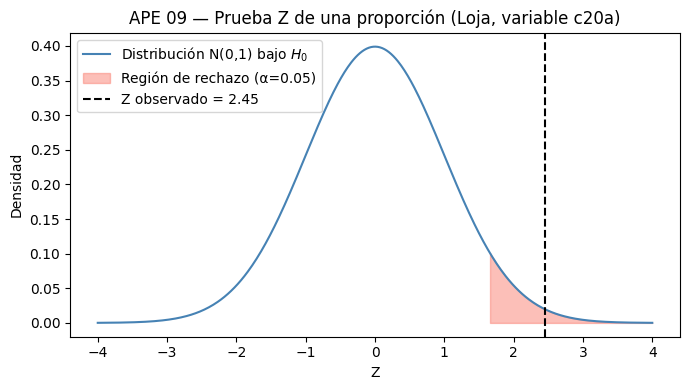

In [ ]:
# Visualización: distribución muestral de Z bajo H0 y ubicación del estadístico observado
x = np.linspace(-4, 4, 500)
y = st.norm.pdf(x)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(x, y, color='steelblue', label='Distribución N(0,1) bajo $H_0$')
ax.fill_between(x, y, where=(x >= st.norm.ppf(1-alpha)), color='salmon', alpha=0.5,
                 label=f'Región de rechazo (α={alpha})')
ax.axvline(z_stat, color='black', linestyle='--', label=f'Z observado = {z_stat:.2f}')
ax.set_title('APE 09 — Prueba Z de una proporción (Loja, variable c20a)')
ax.set_xlabel('Z')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()


## 3. APE 10 — Prueba de Hipótesis Unimuestral (T de Student para una media)

### Variable analizada
`c01`: *"Con relación al mes anterior, ¿la situación económica de su hogar es:
Mejor(1) / Igual(2) / Peor(3)?"*

Siguiendo la metodología estándar de los **índices de confianza del consumidor**
(saldo neto de respuestas), la variable ordinal se recodifica en una escala de
intervalo simétrica:

$$
\text{saldo}_i =
\begin{cases}
+1 & \text{si el hogar respondió "Mejor"} \\
\ 0 & \text{si el hogar respondió "Igual"} \\
-1 & \text{si el hogar respondió "Peor"}
\end{cases}
$$

El parámetro crítico es la **media poblacional del saldo** $\mu$ para los hogares de
Loja. Un valor $\mu = 0$ representa una percepción neutra (ni mejora ni deterioro).

### Planteamiento de hipótesis

$$
H_0: \mu = 0 \qquad \text{(percepción promedio neutra sobre la economía del hogar)}
$$
$$
H_1: \mu < 0 \qquad \text{(percepción promedio de deterioro económico del hogar)}
$$

### Estadístico de prueba

Como la varianza poblacional $\sigma^2$ es desconocida y se estima a partir de la
muestra ($s^2$), se utiliza el estadístico **T de Student**:

$$
T = \frac{\bar{x} - \mu_0}{\dfrac{s}{\sqrt{n}}} \sim t_{(n-1)}
$$

con $n-1$ grados de libertad, contraste de **una sola cola (izquierda)** y
$\alpha = 0.05$.

In [ ]:
# ---------------------------------------------------------
# APE 10: Prueba T de Student para una media (scipy.stats)
# ---------------------------------------------------------

# Recodificación de la escala ordinal Mejor/Igual/Peor a saldo neto (+1, 0, -1)
mapa_saldo = {1: 1, 2: 0, 3: -1}
loja['saldo_c01'] = loja['c01'].map(mapa_saldo)

mu0 = 0.0
media_muestral = loja['saldo_c01'].mean()
desv_muestral = loja['saldo_c01'].std(ddof=1)
n_loja = len(loja)

# ttest_1samp: prueba T de una muestra contra la media hipotética mu0
# alternative='less' -> contraste de cola izquierda: H1: mu < mu0
t_stat, p_value_t = st.ttest_1samp(loja['saldo_c01'], popmean=mu0, alternative='less')

print("----- APE 10: Prueba T de Student de una media -----")
print(f"n (Loja)                 = {n_loja}")
print(f"Media muestral (saldo)   = {media_muestral:.4f}")
print(f"Desviación estándar (s)  = {desv_muestral:.4f}")
print(f"Grados de libertad       = {n_loja - 1}")
print(f"Estadístico T            = {t_stat:.4f}")
print(f"Valor-p                  = {p_value_t:.8f}")
print(f"Nivel de significancia α = {alpha}")


----- APE 10: Prueba T de Student de una media -----
n (Loja)                 = 300
Media muestral (saldo)   = -0.1367
Desviación estándar (s)  = 0.4605
Grados de libertad       = 299
Estadístico T            = -5.1407
Valor-p                  = 0.00000025
Nivel de significancia α = 0.05


In [ ]:
# Decisión estadística basada en el valor-p
print("----- Decisión estadística (APE 10) -----")
if p_value_t < alpha:
    print(f"Valor-p ({p_value_t:.8f}) < α ({alpha})  ->  Se RECHAZA H0.")
    print("Conclusión: existe evidencia estadísticamente significativa de que, en promedio,")
    print("los hogares de Loja perciben un DETERIORO de su situación económica respecto")
    print("al mes anterior (saldo neto medio significativamente menor que 0).")
else:
    print(f"Valor-p ({p_value_t:.8f}) >= α ({alpha})  ->  No se rechaza H0.")
    print("Conclusión: no hay evidencia suficiente para afirmar que la percepción")
    print("económica promedio de los hogares de Loja sea negativa.")


----- Decisión estadística (APE 10) -----
Valor-p (0.00000025) < α (0.05)  ->  Se RECHAZA H0.
Conclusión: existe evidencia estadísticamente significativa de que, en promedio,
los hogares de Loja perciben un DETERIORO de su situación económica respecto
al mes anterior (saldo neto medio significativamente menor que 0).


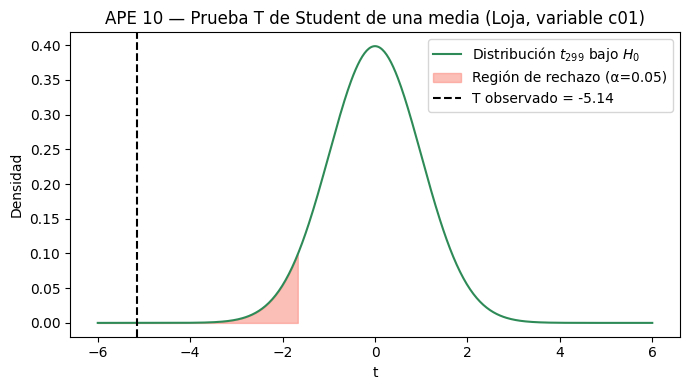

In [ ]:
# Visualización: distribución t bajo H0 y ubicación del estadístico observado
gl = n_loja - 1
x = np.linspace(-6, 6, 500)
y = st.t.pdf(x, df=gl)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(x, y, color='seagreen', label=f'Distribución $t_{{{gl}}}$ bajo $H_0$')
ax.fill_between(x, y, where=(x <= st.t.ppf(alpha, df=gl)), color='salmon', alpha=0.5,
                 label=f'Región de rechazo (α={alpha})')
ax.axvline(t_stat, color='black', linestyle='--', label=f'T observado = {t_stat:.2f}')
ax.set_title('APE 10 — Prueba T de Student de una media (Loja, variable c01)')
ax.set_xlabel('t')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Conclusiones Generales

| Prueba | Parámetro | Estadístico | Valor-p | Decisión (α = 0.05) |
|---|---|---|---|---|
| APE 09 — Z de una proporción | $p$ (empleo percibido "Peor") | $Z$ | ver salida | Rechazo/No rechazo de $H_0$ |
| APE 10 — T de Student de una media | $\mu$ (saldo neto situación económica del hogar) | $T$ | ver salida | Rechazo/No rechazo de $H_0$ |

Ambas pruebas se aplicaron exclusivamente sobre la submuestra de la **provincia de
Loja** dentro del módulo de Confianza del Consumidor de la ENEMDU (enero 2026),
utilizando los estadísticos paramétricos apropiados según el tipo de variable:

- **Proporción** (variable categórica binaria derivada) → **Prueba Z**, justificada
  por el cumplimiento de la condición de normalidad asintótica $n\hat p \ge 5$ y
  $n(1-\hat p) \ge 5$.
- **Media** (variable de intervalo construida mediante saldo neto) → **Prueba T de
  Student**, justificada por el desconocimiento de la varianza poblacional y el
  uso de la varianza muestral $s^2$ como estimador.

En ambos casos, la decisión se fundamentó estrictamente en la comparación del
**valor-p** contra el nivel de significancia $\alpha = 0.05$, siguiendo la regla:

$$
\text{Si } p\text{-valor} < \alpha \Rightarrow \text{Rechazar } H_0
$$
$$
\text{Si } p\text{-valor} \ge \alpha \Rightarrow \text{No rechazar } H_0
$$
